### Assessing Women's General Living Standards in Kenya
The aim of this project is to gain a general picture as to which parts of Kenya offer a good economic living standard for women.
Additionally, this aims to try and understand which particular factors improve this living standard. Which places are women more likely to get employed? 
And if employed, are they paid? Do they control their own finances?

One must also ask if cultural practices hinder the general standard of living enjoyed by these women. Where are they more likely to experience domestic violence or cultural practices such as FGM? Do they have a liberating sexual life free of sexual coercion from partners? These are some of the data points and datasets that are being used to investigate the living standards of Kenyan women by county level.

The datasets below encompass the following information(in order):
1. The amount of agricultural land that women own 
2. The rate of employment of women per county
3. The liberty of women to negotiate for sexual affairs
4. The amount of non-agricultural land women own
5. The rate of poverty of women per county
6. Women house ownership
7. Freedom of women to control their own finances
8. Teenage fertility per county
9. The number of literate women in every county

Data Sources: S
Kenya Health & Demographic Survey 2022
Kenya Poverty Report 2022

In [1]:
import pandas as pd

df_ag_land_ownership = pd.read_excel("Agricultural_Land_Ownership_Data_Kenya.xlsx")
df_employment = pd.read_excel("Data_for_Employment_by_County_Women.xlsx")
df_sex_negotiation = pd.read_excel("Data_on_Negotiation_for_Sex.xlsx")
df_non_ag_land_ownership = pd.read_excel("Data_on_Women's_Land_Ownership_Kenya(non-agricultural land).xlsx")
df_poverty = pd.read_excel("Data_Poverty_Rate_2022.xlsx")
df_house_land_ownership = pd.read_excel("Kenya_Women_House_Land_Ownership.xlsx")
df_finance_control = pd.read_excel("Kenya_Women's_Cash_Control.xlsx")
df_teen_fertility = pd.read_excel("Teenage_fertility_in_Kenya .xlsx")
df_violence_women = pd.read_excel("Violence_on_Women.xlsx")
df_women_literacy = pd.read_excel("Women_Literacy_Kenya.xlsx")


print(df_women_literacy.head())
print(df_teen_fertility.head())

       County  Higher than secondary schooling  Can read a whole sentence  \
0     Mombasa                             21.0                       64.9   
1       Kwale                              7.3                       54.7   
2      Kilifi                              8.5                       67.8   
3  Tana River                              3.3                       39.0   
4        Lamu                              8.9                       70.4   

   Can read part of a sentence  Cannot read at all  Blind/visually impaired  \
0                          4.3                 9.8                      0.0   
1                         19.8                18.0                      0.1   
2                          4.7                19.0                      0.0   
3                          8.3                49.4                      0.0   
4                          4.9                15.8                      0.0   

   Total  Percentage literate  Number of women  
0    100     

### Data Cleaning and Feature Engineering

Extracting information from the different datasets in order to concatanate them


In [2]:
#Agricultural land ownership women
df_clean_agric_data = []

df_clean_agric_data = df_ag_land_ownership .drop(columns = ["Do not own agricultural land", "Total","Total (Deed)", "Number of women (Owners)", "Woman's name is not on title deed", "Does not have a title deed", "Number of women (Total)"])


#new column on actual title deed owner
df_clean_agric_data["Total_Who_Own_Land(Agric)"] = df_clean_agric_data["Own land (Alone)"] + df_clean_agric_data["Own land (Jointly)"] + df_clean_agric_data["Own land (Both alone and jointly)"]

# Convert both problematic columns to numeric
df_clean_agric_data["Total_Who_Own_Land(Agric)"] = pd.to_numeric(df_clean_agric_data["Total_Who_Own_Land(Agric)"], errors='coerce')
df_clean_agric_data["Woman's name is on title deed"] = pd.to_numeric(df_clean_agric_data["Woman's name is on title deed"], errors='coerce')

#fillnulls
#4 counties have no data on title deeds for women
df_clean_agric_data["Woman's name is on title deed"].fillna(0)


df_clean_agric_data["Title_Deed_Owners(Agric)"] = df_clean_agric_data["Total_Who_Own_Land(Agric)"] * (df_clean_agric_data["Woman's name is on title deed"] * 0.01)


print(df_clean_agric_data.head(20))



           County  Own land (Alone)  Own land (Jointly)  \
0         Mombasa               1.8                 7.3   
1           Kwale               2.3                16.4   
2          Kilifi               1.9                14.2   
3      Tana River               1.3                17.2   
4            Lamu               4.2                19.5   
5    Taita/Taveta               2.0                10.6   
6         Garissa               0.1                 1.7   
7           Wajir               0.9                 0.7   
8         Mandera               0.4                 1.1   
9        Marsabit               0.7                 1.6   
10         Isiolo               1.0                 7.8   
11           Meru               6.5                27.3   
12  Tharaka-Nithi               5.8                19.1   
13           Embu               1.8                 9.3   
14          Kitui               3.4                32.2   
15       Machakos               3.3                36.2 

In [3]:
df_clean_non_agric_data = df_non_ag_land_ownership[[
    "County", 
    "Own land (Alone)",
    "Own land (Jointly)", 
    "Own land (Both)",
    "Name on title deed"
]].copy()
df_clean_non_agric_data["total_land_owned(non-agric)"] = df_clean_non_agric_data["Own land (Alone)"] + df_clean_non_agric_data["Own land (Jointly)"] + df_clean_non_agric_data["Own land (Both)"]
df_clean_non_agric_data = df_clean_non_agric_data.drop(columns=["Name on title deed"])

df_clean_non_agric_data.rename(columns={"Own land (Alone)":"Own_Land_Alone(Non-Agric)", "Own land (Jointly)" : "Own_Land_Jointly(Non_Agric)", "Own land (Both)": "Own_Both_Jointly_Alone(Non-Agric)"}, inplace=True)
df_clean_non_agric_data.head(40)

,County,Own_Land_Alone(Non-Agric),Own_Land_Jointly(Non_Agric),Own_Both_Jointly_Alone(Non-Agric),total_land_owned(non-agric)
0,Mombasa,2.8,3.6,0.0,6.4
1,Kwale,0.2,1.5,0.0,1.7
2,Kilifi,0.8,1.7,0.0,2.5
3,Tana River,0.8,4.9,0.0,5.7
4,Lamu,0.7,6.1,0.0,6.8
5,Taita/Taveta,1.9,2.0,0.2,4.1
6,Garissa,1.5,0.5,0.0,2.0
7,Wajir,2.9,0.5,0.0,3.4
8,Mandera,0.0,1.0,0.2,1.2
9,Marsabit,0.4,3.2,0.5,4.1


In [4]:
df_employment_cleaned = []

df_employment_cleaned = df_employment.drop(columns=["Number of women (total)", "Total", "Number of women (employed)", "In-kind only", "Not paid"])

#replacing star(blank) with NaN
df_employment_cleaned["Cash only"] = pd.to_numeric(df_employment_cleaned["Cash only"], errors='coerce')
df_employment_cleaned["Cash and in-kind"] = pd.to_numeric(df_employment_cleaned["Cash and in-kind"], errors='coerce')

#Replacing NaN with means
df_employment_cleaned['Cash only'] = df_employment_cleaned['Cash only'].fillna(df_employment_cleaned['Cash only'].mean())
df_employment_cleaned['Cash and in-kind'] = df_employment_cleaned['Cash and in-kind'].fillna(df_employment_cleaned['Cash and in-kind'].mean())
df_employment_cleaned.head(20)

,County,% Employed in last 12 months,Cash only,Cash and in-kind
0,Mombasa,61.6,93.700000,0.300000
1,Kwale,26.1,96.000000,2.100000
2,Kilifi,59.3,96.400000,1.900000
3,Tana River,22.6,73.300000,0.000000
4,Lamu,57.9,74.100000,1.100000
5,Taita/Taveta,59.5,78.400000,18.400000
6,Garissa,19.0,78.600000,13.500000
7,Wajir,18.4,43.700000,5.600000
8,Mandera,5.3,73.367391,5.008696
9,Marsabit,5.2,73.367391,5.008696


In [5]:
#Datasets that only require basic cleaning
df_sex_negotiation_cleaned = []

#Choosing relevent features
df_sex_negotiation_cleaned  = df_sex_negotiation.drop(columns=["Number of women"])
df_teen_fertility_cleaned = df_teen_fertility[["County","Have ever been pregnant"]].copy()
df_women_literacy_cleaned = df_women_literacy[["County", "Higher than secondary schooling", "Can read a whole sentence"]].copy()
df_house_land_ownership_cleaned = df_house_land_ownership[["County", "Own a house (Alone)", "Own a house (Jointly)"]].copy()
df_violence_women_cleaned = df_violence_women[["County", "Percentage who have experienced physical violence since age 15"]].copy()

#df_employment_cleaned.head()
#df_teen_fertility_cleaned.head()


In [6]:
#feature engineering for above datasets
df_house_land_ownership_cleaned["House_ownership"] = df_house_land_ownership_cleaned["Own a house (Alone)"] + df_house_land_ownership_cleaned["Own a house (Jointly)"]
df_house_land_ownership_cleaned = df_house_land_ownership_cleaned.drop(columns=["Own a house (Alone)", "Own a house (Jointly)"])

#women literacy
df_women_literacy_cleaned["functional_literacy"] = df_women_literacy_cleaned["Can read a whole sentence"]

df_house_land_ownership_cleaned.head()


,County,House_ownership
0,Mombasa,16.7
1,Kwale,33.6
2,Kilifi,29.5
3,Tana River,50.3
4,Lamu,35.4


In [7]:
#according to Poverty Measures in Kenya Poverty Report 2022
national_female_poverty_headcount = 35.3
national_female_poverty_gap = 9.5
national_female_poor_distribution = 34.4


#poverty rate data cleaning
df_poverty_cleaned = df_poverty.drop(index=[0, 1, 2], columns =["Number of Poor ('000)", "Population ('000)"] ).copy()
df_poverty_cleaned.rename(columns={'Residence / County': 'County'}, inplace=True)
#feature engineering 
df_poverty_cleaned["Female_Headcount_Rate(%)"] = df_poverty_cleaned["Headcount Rate (%)"] * (national_female_poverty_headcount/100) 
df_poverty_cleaned["Female_poverty_gap(%)"] = df_poverty_cleaned["Poverty Gap (%)"] * (national_female_poverty_gap/100)
df_poverty_cleaned["Distribution_of_poor(females)(%)"] = df_poverty_cleaned["Distribution of the Poor (%)"] * (national_female_poor_distribution/100)
#df_poverty_cleaned.head(20)
#comment out the last df.head() to see the transition that has happened in the code

#removing mixed gender national stats
df_poverty_cleaned = df_poverty_cleaned.drop(columns=["Headcount Rate (%)", "Distribution of the Poor (%)", "Poverty Gap (%)", "Severity of Poverty (%)"])
df_poverty_cleaned.head(20)

,County,Female_Headcount_Rate(%),Female_poverty_gap(%),Distribution_of_poor(females)(%)
3,Mombasa,9.5310,0.5415,0.5848
4,Kwale,18.0383,1.4155,0.7912
5,Kilifi,18.7090,1.3775,1.4104
6,Tana River,23.5451,2.0995,0.3784
7,Lamu,12.5668,0.7315,0.1032
8,Taita/Taveta,13.8729,0.7220,0.2408
9,Garissa,23.9334,2.1660,1.0320
10,Wajir,22.8391,1.8240,0.9288
11,Mandera,25.7337,2.3655,1.1352
12,Marsabit,23.3333,2.3465,0.5504


In [8]:
#women finance control
df_finance_cleaned = df_finance_control[["County", "Decided by Wife", "Wife and Husband Jointly", "Earned More than Husband"]].copy()

#renaming
df_finance_cleaned.rename(columns={"Decided by Wife": "Finances_Decided_By_Wife", "Wife and Husband Jointly":"Finances_Decided_Jointly_Spouses" }, inplace=True)
df_finance_cleaned[["Finances_Decided_By_Wife", "Finances_Decided_Jointly_Spouses", "Earned More than Husband"]] = df_finance_cleaned[["Finances_Decided_By_Wife", "Finances_Decided_Jointly_Spouses", "Earned More than Husband"]].apply(pd.to_numeric, errors = 'coerce')
df_finance_cleaned.fillna(0)
df_finance_cleaned.head(40)

,County,Finances_Decided_By_Wife,Finances_Decided_Jointly_Spouses,Earned More than Husband
0,Mombasa,61.6,33.8,9.9
1,Kwale,45.4,52.7,14.8
2,Kilifi,44.7,52.4,13.8
3,Tana River,42.2,53.8,3.7
4,Lamu,35.1,60.3,5.9
5,Taita/Taveta,55.6,39.1,13.1
6,Garissa,23.2,70.3,2.4
7,Wajir,82.8,17.2,5.6
8,Mandera,NaN,NaN,NaN
9,Marsabit,NaN,NaN,NaN


## Concatanating
The next section aims to unite all the datasets into a single large one that has all the information from the above cleaned datasets.

Finally, it stores that information into an excel file for easy storage of information.

In [ ]:
import pandas as pd

# List of your DataFrames
dfs = [df_poverty_cleaned, df_clean_agric_data, df_employment_cleaned, df_house_land_ownership_cleaned, df_sex_negotiation_cleaned, df_teen_fertility_cleaned, df_violence_women_cleaned, df_women_literacy_cleaned, df_house_land_ownership_cleaned, df_finance_cleaned]

# Set the key as the index for all dfs, then concat along columns
df_final = pd.concat([df.set_index("County") for df in dfs], axis=1, join='outer').reset_index()

#final df feature engineering
df_final  = df_final.drop(index=[47,48])
# Drop the duplicate column completely
df_final = df_final.loc[:, ~df_final.columns.duplicated()].copy()

# Verify it's gone (this should print '1' if deduplication worked)
print(f"Occurrences of House_ownership: {list(df_final.columns).count('House_ownership')}")


Occurrences of House_ownership: 1


In [10]:
#Exporting the combined clean table to a excel file
df_final.head(50)
#df_final.to_excel("State_of_Women.xlsx", index=False) #done once

,County,Female_Headcount_Rate(%),Female_poverty_gap(%),Distribution_of_poor(females)(%),Own land (Alone),Own land (Jointly),Own land (Both alone and jointly),Woman's name is on title deed,Total_Who_Own_Land(Agric),Title_Deed_Owners(Agric),...,Can say no to sexual intercourse,Can ask husband to use a condom,Have ever been pregnant,Percentage who have experienced physical violence since age 15,Higher than secondary schooling,Can read a whole sentence,functional_literacy,Finances_Decided_By_Wife,Finances_Decided_Jointly_Spouses,Earned More than Husband
0,Mombasa,9.5310,0.5415,0.5848,1.8,7.3,0.1,30.2,9.2,2.7784,...,41.9,34.3,10.8,24.5,21.0,64.9,64.9,61.6,33.8,9.9
1,Kwale,18.0383,1.4155,0.7912,2.3,16.4,0.0,8.2,18.7,1.5334,...,28.9,32.3,14.8,13.1,7.3,54.7,54.7,45.4,52.7,14.8
2,Kilifi,18.7090,1.3775,1.4104,1.9,14.2,0.2,9.2,16.3,1.4996,...,40.6,36.7,12.5,20.1,8.5,67.8,67.8,44.7,52.4,13.8
3,Tana River,23.5451,2.0995,0.3784,1.3,17.2,0.2,1.5,18.7,0.2805,...,36.5,20.4,17.6,35.8,3.3,39.0,39.0,42.2,53.8,3.7
4,Lamu,12.5668,0.7315,0.1032,4.2,19.5,0.2,11.5,23.9,2.7485,...,40.2,32.2,13.7,33.9,8.9,70.4,70.4,35.1,60.3,5.9
5,Taita/Taveta,13.8729,0.7220,0.2408,2.0,10.6,0.0,15.5,12.6,1.9530,...,33.1,33.3,18.4,29.5,14.7,71.6,71.6,55.6,39.1,13.1
6,Garissa,23.9334,2.1660,1.0320,0.1,1.7,0.0,NaN,1.8,NaN,...,12.7,6.5,14.8,21.0,6.1,25.1,25.1,23.2,70.3,2.4
7,Wajir,22.8391,1.8240,0.9288,0.9,0.7,0.0,NaN,1.6,NaN,...,32.8,10.3,10.8,13.2,2.9,23.8,23.8,82.8,17.2,5.6
8,Mandera,25.7337,2.3655,1.1352,0.4,1.1,0.2,NaN,1.7,NaN,...,9.6,3.8,14.6,8.6,1.5,19.1,19.1,NaN,NaN,NaN
9,Marsabit,23.3333,2.3465,0.5504,0.7,1.6,0.0,NaN,2.3,NaN,...,22.5,20.8,29.4,16.4,3.1,18.5,18.5,NaN,NaN,NaN


## Visualization and Understanding Data
This data can be grouped into different sets of categories. In doing so, different features can contribute in their own way to the living standards of a given individual in any county.
Some of these features are negative and the higher the prevalence, the worse the assumed outcome in living standards. For instance, higher prevalence in teenage pregnany and violence on women means it is not considered safer or a good environment to be in. 

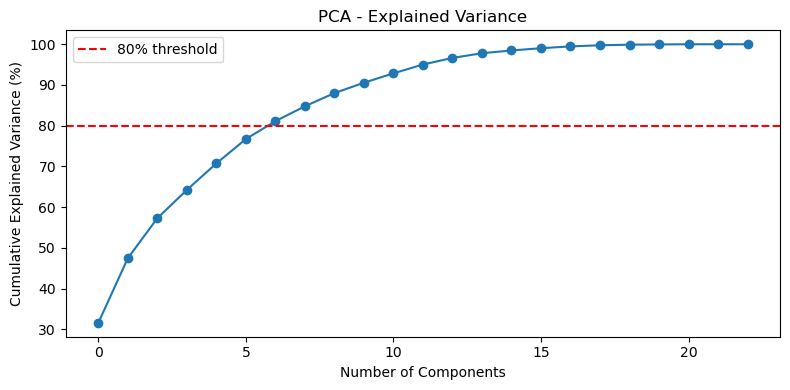

Components needed for 80% variance: 7
                 PC1       PC2       PC3       PC4       PC5       PC6  \
County                                                                   
Mombasa    -0.675729  3.571563  0.737689 -0.243791  0.288847  0.637016   
Kwale       2.510676  0.390204 -0.684572  1.490615  0.374174  0.674560   
Kilifi      0.949211  0.820825 -0.583540  1.568642 -0.608307  1.369122   
Tana River  3.810514 -1.716056 -0.718850  0.855585  0.116185 -0.398351   
Lamu       -0.491510  0.160725 -1.515067  1.366367  0.485134 -1.851236   

                 PC7       PC8       PC9      PC10  ...      PC14      PC15  \
County                                              ...                       
Mombasa    -0.205213 -0.435290 -1.004860 -0.296898  ... -0.141520  0.553566   
Kwale      -0.654190 -1.327028 -0.104530 -1.070096  ... -0.572313 -0.144619   
Kilifi      0.795611 -1.618093  0.693450 -0.225353  ...  0.392456 -0.034765   
Tana River  1.287497 -0.350895 -1.459870  0.1830

In [11]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

#Select only numeric columns and handle NaNs
df_pca_input = df_final.select_dtypes(include=[np.number])
df_pca_input = df_pca_input.fillna(df_pca_input.mean())

#Set county name as index before PCA
df_final = df_final.set_index('County')  # replace 'County' with your actual column name


#Standardize
scaler = StandardScaler()
X_scaled= scaler.fit_transform(df_pca_input)
#Run PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

#Explained variance plot
plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_) * 100, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.title('PCA - Explained Variance')
plt.axhline(80, color='red', linestyle='--', label='80% threshold')
plt.legend()
plt.tight_layout()
plt.show()

#See how many components explain 80% variance
n_80 = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.80) + 1
print(f"Components needed for 80% variance: {n_80}")

#PCA scores as a DataFrame
pc_cols = [f'PC{i+1}' for i in range(X_pca.shape[1])]
df_pca_scores = pd.DataFrame(X_pca, columns=pc_cols, index=df_final.index)
print(df_pca_scores.head())

## PCA Explanation
We are using PCA to reduce dimensionality as there are more than 20 features we are using in order to understand the state of women in the country.
What the above graph shows us is that there are only 7 PC components that contribute to 80% of the variance.

In [12]:
# Keep first 6 components
pca_6 = PCA(n_components=6)
X_pca_6 = pca_6.fit_transform(X_scaled)

df_pca_scores = pd.DataFrame(
    X_pca_6,
    columns=[f'PC{i+1}' for i in range(6)],
    index=df_final.index
)

loadings = pd.DataFrame(
    pca_6.components_.T,
    index=df_pca_input.columns,
    columns=[f'PC{i+1}' for i in range(6)]
)

# For each PC, see which variables drive it most
for pc in ['PC1','PC2','PC3','PC4','PC5','PC6']:
    print(f"\n--- {pc} ---")
    print(loadings[pc].abs().sort_values(ascending=False).head(4))


--- PC1 ---
functional_literacy             0.330337
Can read a whole sentence       0.330337
% Employed in last 12 months    0.327410
Female_poverty_gap(%)           0.313746
Name: PC1, dtype: float64

--- PC2 ---
House_ownership                  0.447476
Woman's name is on title deed    0.407760
Own land (Jointly)               0.382241
Total_Who_Own_Land(Agric)        0.379434
Name: PC2, dtype: float64

--- PC3 ---
Finances_Decided_By_Wife            0.543199
Finances_Decided_Jointly_Spouses    0.541448
Cash and in-kind                    0.337273
Cash only                           0.306947
Name: PC3, dtype: float64

--- PC4 ---
Title_Deed_Owners(Agric)                                          0.488562
Woman's name is on title deed                                     0.353080
Have ever been pregnant                                           0.330308
Percentage who have experienced physical violence since age 15    0.327512
Name: PC4, dtype: float64

--- PC5 ---
Earned More than Hu

## Visualizations of different PCs

/tmp/ipykernel_4535/983507743.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.annotate(county, (df_pca_scores['PC1'][i], df_pca_scores['PC2'][i]))


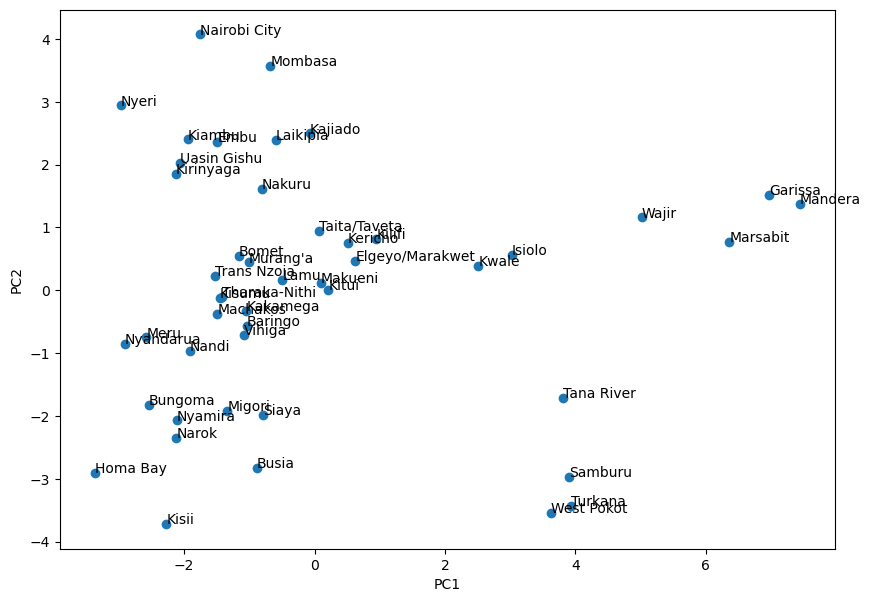

In [ ]:
import matplotlib.pyplot as plt

# Graphing PC2 against PC1
plt.figure(figsize=(10,7))
plt.scatter(df_pca_scores['PC1'], df_pca_scores['PC2'])
for i, county in enumerate(df_final.index):
    plt.annotate(county, (df_pca_scores['PC1'][i], df_pca_scores['PC2'][i]))
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

/tmp/ipykernel_4535/90743510.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.annotate(county, (df_pca_scores['PC1'][i], df_pca_scores['PC3'][i]))


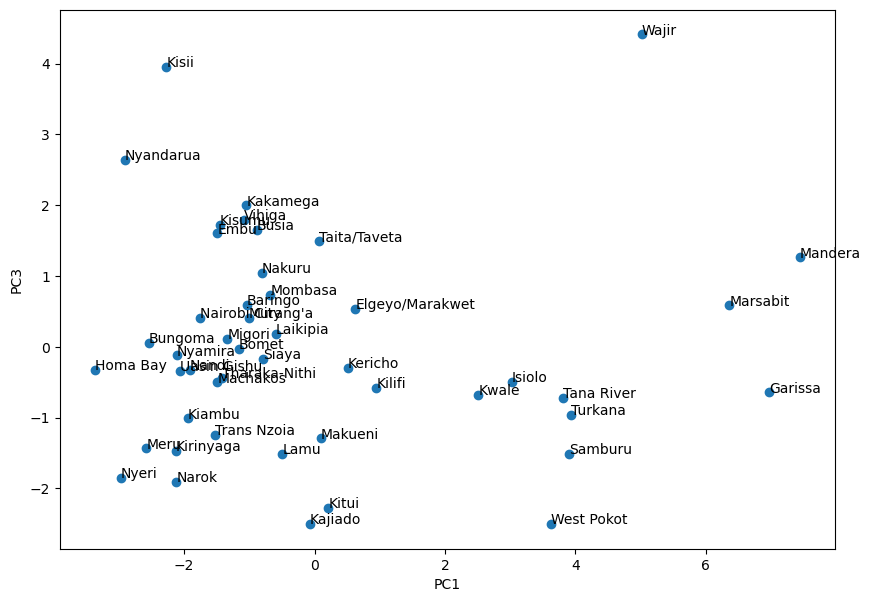

In [ ]:
import matplotlib.pyplot as plt

# Graphing PC3 against PC1
plt.figure(figsize=(10,7))
plt.scatter(df_pca_scores['PC1'], df_pca_scores['PC3'])
for i, county in enumerate(df_final.index):
    plt.annotate(county, (df_pca_scores['PC1'][i], df_pca_scores['PC3'][i]))
plt.xlabel('PC1')
plt.ylabel('PC3')
plt.show()

## Performing Tests
Null hypothesis: The location of a person in a different county does not affect their living standards

Alternate hypothesis: People living in different counties with more favorable climates enjoy a better standard of living

In [ ]:
from scipy import stats

# Split counties into two groups (e.g., based on a threshold or geography)
# Let's say we have a list of Northern/ASAL counties
asal_counties = ['Turkana', 'Mandera', 'Wajir', 'Garissa', 'Marsabit', 'Samburu']
group_asal = df_pca_scores.loc[df_pca_scores.index.isin(asal_counties), 'PC1']
group_other = df_pca_scores.loc[~df_pca_scores.index.isin(asal_counties), 'PC1']

# Run the T-test
t_stat, p_val = stats.ttest_ind(group_asal, group_other)

print(f"T-statistic: {t_stat}, P-value: {p_val}")

T-statistic: 8.793461598296744, P-value: 2.485897468359385e-11


P_value is significantly smaller than 0.05 so we can go with the alternate hypothesis that we had formulated.

## Regression

In [16]:
import statsmodels.api as sm

# Define your target (y) - e.g., Overall County Poverty Headcount
y = df_final['Female_Headcount_Rate(%)'] 

# Define your predictors 
X = df_pca_scores[['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6']]
X = sm.add_constant(X) # Adds an intercept (beta_0)

# Fit the model
model = sm.OLS(y, X).fit()

print(model.summary())

                               OLS Regression Results                               
Dep. Variable:     Female_Headcount_Rate(%)   R-squared:                       0.860
Model:                                  OLS   Adj. R-squared:                  0.839
Method:                       Least Squares   F-statistic:                     41.09
Date:                      Mon, 20 Apr 2026   Prob (F-statistic):           1.37e-15
Time:                              18:23:43   Log-Likelihood:                -98.422
No. Observations:                        47   AIC:                             210.8
Df Residuals:                            40   BIC:                             223.8
Df Model:                                 6                                         
Covariance Type:                  nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------

## Explanation
By observing the above table, we can see that three components i.e PC1, PC2 and PC6 have a P-value that is less than 0.05. These are the most statistically significant PCs. We can also understand that other PCs here that contain features such as "Physical Violence" might contribute to the general wellbeing or lack thereof but it does not entirely tell the story of the economic threshold.

Additionally, we can see that the model has an F-statistic of 1.37e-15 meaning that this relationship did not emerge by chance.

Asset ownership, as seen in PC2, is significant for the reduction in female poverty headcount.

/tmp/ipykernel_4535/2736437116.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  fitted_values[i] + 0.2, # Shift text slightly to the right
/tmp/ipykernel_4535/2736437116.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  residuals[i] + 0.1,    # Shift text slightly up


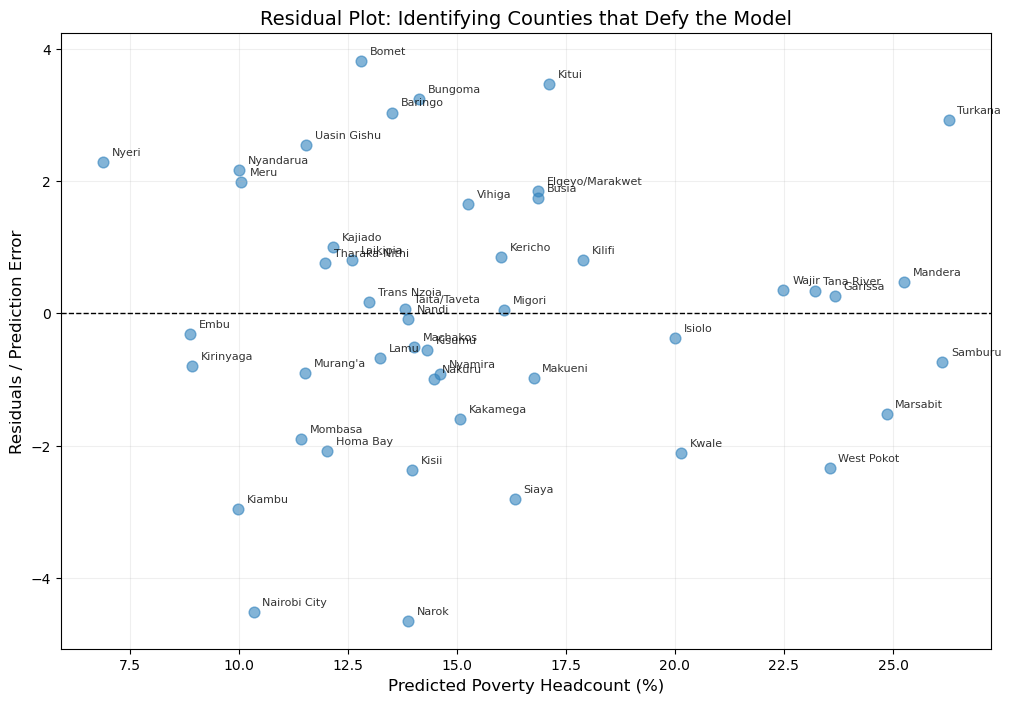

In [17]:
import matplotlib.pyplot as plt

# Calculate the residuals
residuals = model.resid
fitted_values = model.fittedvalues

plt.figure(figsize=(12, 8))
plt.scatter(fitted_values, residuals, color='#3182bd', alpha=0.6, s=60)
plt.axhline(0, color='black', linestyle='--', linewidth=1)

# Labelling the points
for i, county_name in enumerate(df_pca_scores.index):
    plt.text(
        fitted_values[i] + 0.2, # Shift text slightly to the right
        residuals[i] + 0.1,    # Shift text slightly up
        county_name, 
        fontsize=8, 
        alpha=0.8
    )

plt.xlabel('Predicted Poverty Headcount (%)', fontsize=12)
plt.ylabel('Residuals / Prediction Error', fontsize=12)
plt.title('Residual Plot: Identifying Counties that Defy the Model', fontsize=14)
plt.grid(True, alpha=0.2)
plt.show()

The above graph shows that the model is reliable as it appears as a scattered plot. The points have not deviated too far from the center either by a large margin for most counties so we can say that it is attempting well for many of these predictions.

/tmp/ipykernel_4535/3486699484.py:30: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_4535/3486699484.py:33: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_4535/3486699484.py:35: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



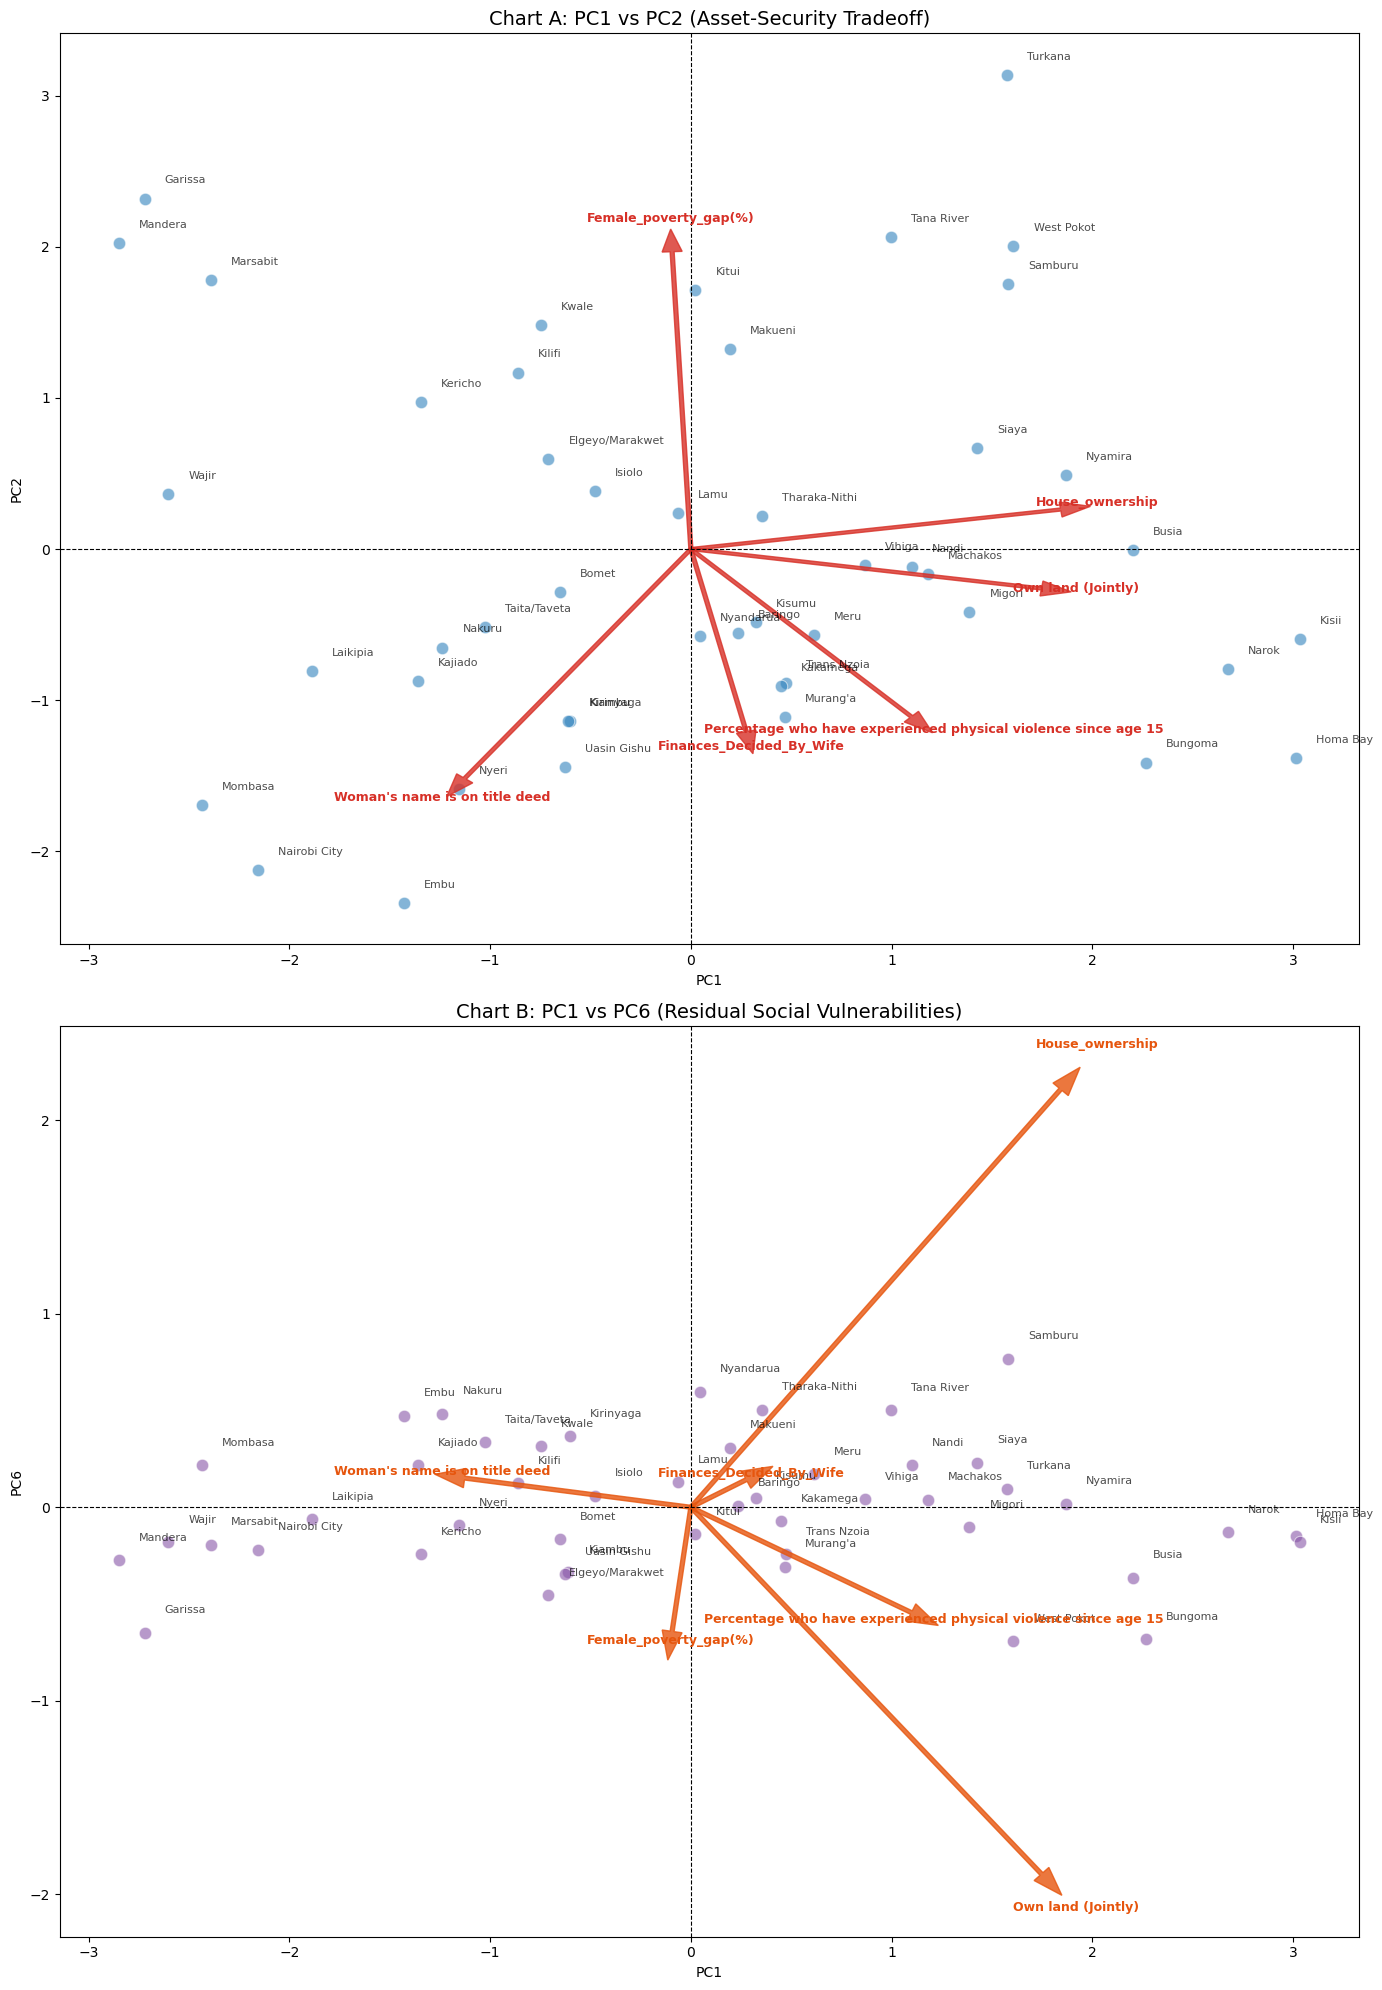

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


#Standardize and Run PCA
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_final)

pca = PCA(n_components=6)
pca_results = pca.fit_transform(scaled_data)

#Create Plotting DataFrames with all 6 PCs
columns = [f'PC{i+1}' for i in range(6)]
pca_df = pd.DataFrame(data=pca_results, columns=columns, index=df_final.index)
loadings = pd.DataFrame(pca.components_.T, columns=columns, index=df_final.columns)

#VISUALIZATION (Two Charts)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 20)) # 2 Rows, 1 Column
scale_factor = 3.0

#CHART 1: PC1 vs PC2 (Assets/Security) 
sns.scatterplot(x='PC1', y='PC2', data=pca_df, s=80, color='#3182bd', alpha=0.6, ax=ax1)
for i in range(pca_df.shape[0]):
    ax1.text(pca_df.PC1[i] + 0.1, pca_df.PC2[i] + 0.1, pca_df.index[i], fontsize=8, alpha=0.7)

for i, feature in enumerate(loadings.index):
    ax1.arrow(0, 0, loadings.PC1[i] * scale_factor, loadings.PC2[i] * scale_factor, 
              color='#d73027', alpha=0.8, width=0.02, head_width=0.1)
    ax1.text(loadings.PC1[i] * (scale_factor + 0.3), loadings.PC2[i] * (scale_factor + 0.3), 
             feature, color='#d73027', ha='center', fontweight='bold', fontsize=9)

ax1.set_title('Chart A: PC1 vs PC2 (Asset-Security Tradeoff)', fontsize=14)
ax1.axhline(0, color='black', lw=0.8, ls='--'); ax1.axvline(0, color='black', lw=0.8, ls='--')

# CHART 2: PC1 vs PC6 (The Specific Vulnerability Axis) 
sns.scatterplot(x='PC1', y='PC6', data=pca_df, s=80, color='#8856a7', alpha=0.6, ax=ax2)
for i in range(pca_df.shape[0]):
    ax2.text(pca_df.PC1.iloc[i] + 0.1, pca_df.PC6.iloc[i] + 0.1, pca_df.index[i], fontsize=8, alpha=0.7)

for i, feature in enumerate(loadings.index):
    ax2.arrow(0, 0, loadings.PC1.iloc[i] * scale_factor, loadings.PC6.iloc[i] * scale_factor, 
              color='#e6550d', alpha=0.8, width=0.02, head_width=0.1)
    ax2.text(loadings.PC1.iloc[i] * (scale_factor + 0.3), loadings.PC6.iloc[i] * (scale_factor + 0.3), 
             feature, color='#e6550d', ha='center', fontweight='bold', fontsize=9)
    
ax2.set_title('Chart B: PC1 vs PC6 (Residual Social Vulnerabilities)', fontsize=14)
ax2.axhline(0, color='black', lw=0.8, ls='--'); ax2.axvline(0, color='black', lw=0.8, ls='--')   

plt.tight_layout()
plt.show()

## Conclusions
Observations from visualizations:
1. In the first chart, as you move to the right, the more asset rich the women are.But it doesn't always indicate that they're financially wealthy as we can see inhabitants of Nairobi, Nyeri and Mombasa in the bottom left. The more dire condition is in the top right where the women are not asset rich and have a high poverty gap.
2. In the second chart, we see asset heaviness on the right side. Interestingly enough, we can also see that owning land jointly does not automatically translate to female poverty. 
3. Both graphs indicate there is a nuanced relationship between financial independence, asset ownership and wealth of women. It also indicates that some could own large tracts of land and still fall under the category of poor people.



